### 03 - Matplotlib + Seaborn

**Documentação Seaborn** - **https://seaborn.pydata.org/**


**Objetivo**
Entender como a visualização funciona internamente (Figure/Axes/Artist) e como escolher gráficos com rigor estatístico.

**Roadmap**
1. Arquitetura de render
2. Escalas e transformações
3. Design orientado à pergunta
4. Visualizações com dados sintéticos (transações e série temporal)
5. Erros de interpretação visual


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
dpi = 300

sns.set_theme(style='whitegrid', context='notebook')


### 1 - Conceito do Zero: Figure, Axes e Artists

Matplotlib segue hierarquia:
- Figure: tela completa
- Axes: área de plotagem
- Artists: objetos desenhados (linhas, textos)

Seaborn atua como camada declarativa sobre essa estrutura.

Tipo do line artist: <class 'matplotlib.lines.Line2D'>


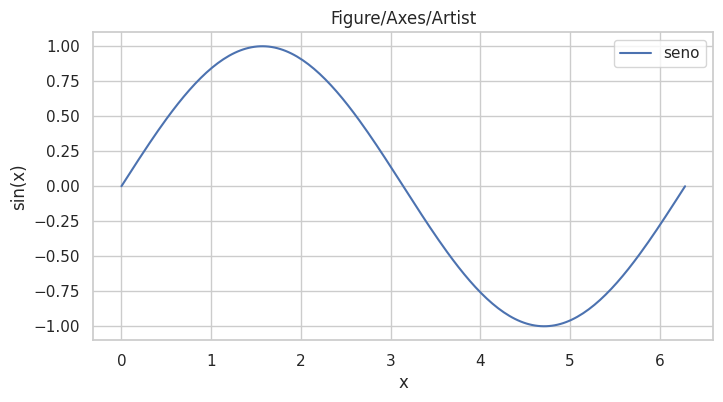

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)
line = ax.plot(x, y, label='seno')[0]
ax.set_title('Figure/Axes/Artist')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.legend()

print('Tipo do line artist:', type(line))
plt.show()


### 2 - Por Baixo dos Panos: pipeline de renderização

Cada chamada de plot adiciona Artists ao Axes. Na renderização:
1. Matplotlib resolve transforms (dados -> coordenadas da tela)
2. backend desenha primitivas
3. display backend exibe bitmap/vetor

Escolha de backend influencia interatividade e qualidade de exportação.

### 3 - Escalas e transformações

Escala linear pode esconder padrão quando a magnitude varia muito.
Escalas logarítmicas frequentemente melhoram legibilidade de caudas longas.

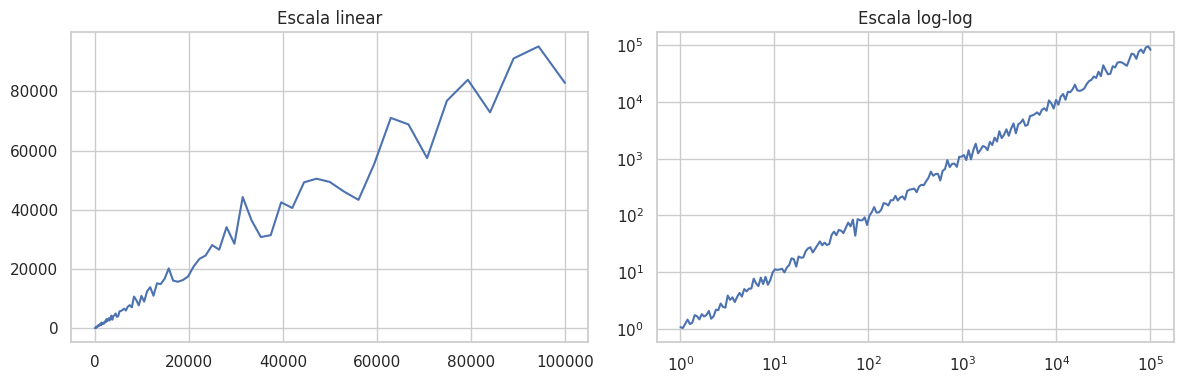

In [32]:
vals = np.logspace(0, 5, 200)
noise = np.random.normal(0, 0.15, size=200)
y = vals * (1 + noise)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vals, y)
axes[0].set_title('Escala linear')

axes[1].plot(vals, y)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Escala log-log')

plt.tight_layout()


### 4 - Escolha de gráfico por pergunta estatística

- Distribuição (variável contínua): prefira **histograma/KDE/ECDF**.
- Relação entre 2 variáveis contínuas: prefira **scatter/regplot**.
- Comparação entre grupos: prefira **box/violin/bar com IC**.
- Série temporal: prefira **linha com agregação temporal**.

Cada tópico abaixo está segmentado em: dados, exemplo menos adequado e exemplo mais adequado.
        


#### 4.1 Distribuição de uma variável contínua

**Pergunta**: como os valores de compra se distribuem?
        


In [ ]:
n_transacoes = 12_000

# Dataset sintético com cauda longa
valores = np.random.lognormal(mean=3.3, sigma=0.8, size=n_transacoes)
df_transacoes = pd.DataFrame({
    'valor': valores,
    'perfil_cliente': np.random.choice(['novo', 'recorrente'], size=n_transacoes, p=[0.35, 0.65])
})

bins_fixos = [0, 20, 40, 80, 160, 320, 640, 1200]
faixas = pd.cut(df_transacoes['valor'], bins=bins_fixos, include_lowest=True)
freq = faixas.value_counts().sort_index()



**Menos adequado para este caso**

Barras em poucas faixas fixas: perde detalhe da forma da distribuição.
        


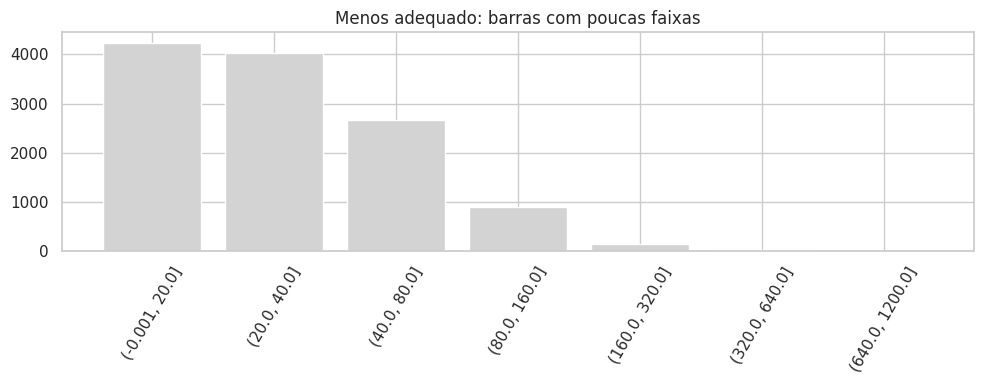

In [34]:
plt.figure(figsize=(10, 4))
plt.bar(freq.index.astype(str), freq.values, color='lightgray')
plt.title('Menos adequado: barras com poucas faixas')
plt.xticks(rotation=60)
plt.tight_layout()



**Mais adequado para este caso**

Histograma e KDE mostram melhor a forma geral e a cauda.
        


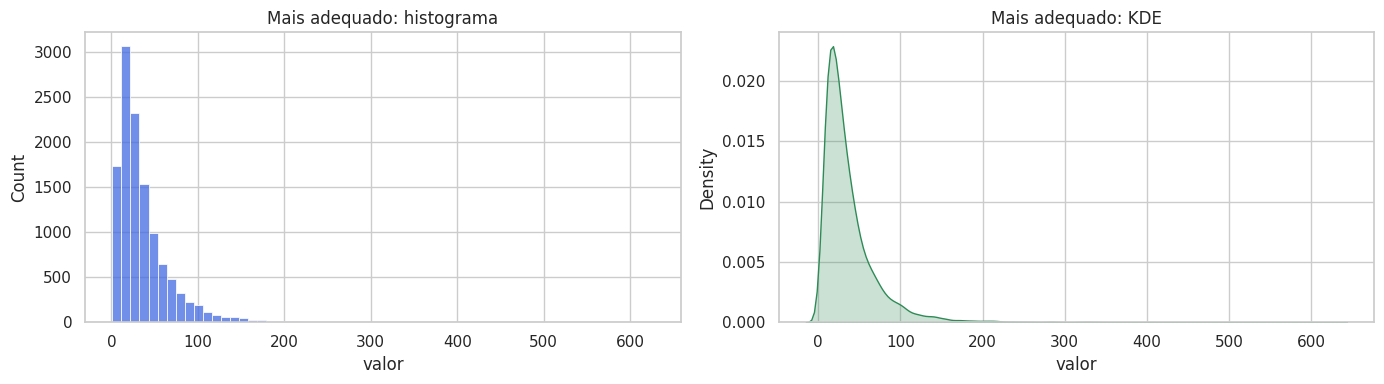

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_transacoes, x='valor', bins=60, ax=axes[0], color='royalblue')
axes[0].set_title('Mais adequado: histograma')

sns.kdeplot(data=df_transacoes, x='valor', fill=True, ax=axes[1], color='seagreen')
axes[1].set_title('Mais adequado: KDE')

plt.tight_layout()



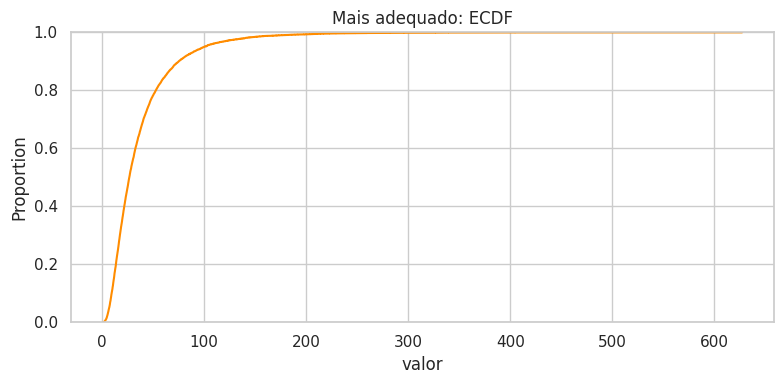

In [36]:
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=df_transacoes, x='valor', color='darkorange')
plt.title('Mais adequado: ECDF')
plt.tight_layout()



#### 4.2 Relação entre variáveis contínuas

**Pergunta**: mais investimento em marketing está associado a mais vendas semanais?
        


In [ ]:
n_relacao = 900
investimento = np.random.uniform(5, 120, size=n_relacao)
ruido = np.random.normal(0, 35, size=n_relacao)
vendas = 40 + 2.7 * investimento + ruido

df_relacao = pd.DataFrame({
    'investimento_marketing': investimento,
    'vendas_semanais': vendas
})

faixas_invest = pd.cut(df_relacao['investimento_marketing'], bins=6)
df_faixas = (
    df_relacao.assign(faixa=faixas_invest)
    .groupby('faixa', observed=True, as_index=False)['vendas_semanais']
    .mean()
)



**Menos adequado para este caso**

Barras por faixa escondem dispersão, outliers e densidade local.
        


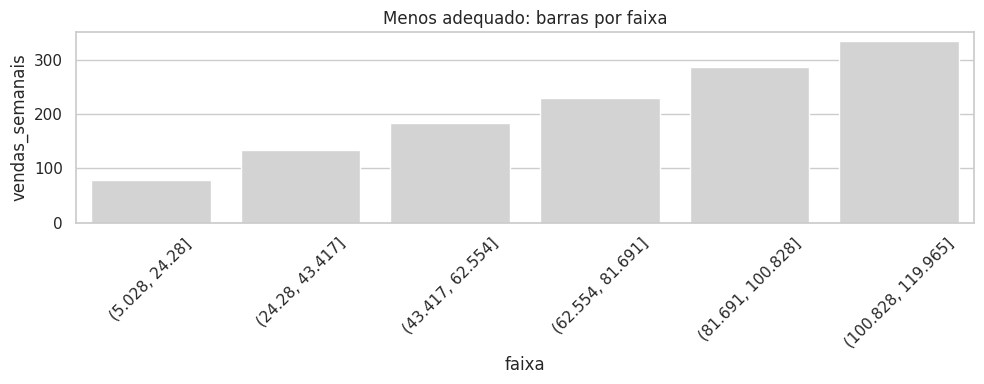

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=df_faixas, x='faixa', y='vendas_semanais', color='lightgray')
plt.title('Menos adequado: barras por faixa')
plt.xticks(rotation=45)
plt.tight_layout()



**Mais adequado para este caso**

Scatter + regplot preserva variabilidade e tendência.
        


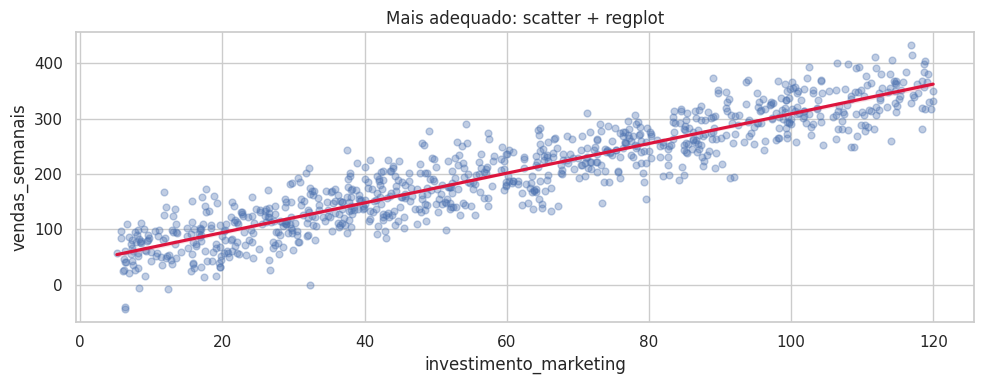

In [ ]:
plt.figure(figsize=(10, 4))
sns.regplot(
    data=df_relacao,
    x='investimento_marketing',
    y='vendas_semanais',
    scatter_kws={'alpha': 0.35, 's': 24},
    line_kws={'color': 'crimson'}
)
plt.title('Mais adequado: scatter + regplot')
plt.tight_layout()



#### 4.3 Comparação entre grupos

**Pergunta**: como o tempo de atendimento muda entre planos?
        


In [ ]:
n_grupos = 1200
plano = np.random.choice(['Basico', 'Intermediario', 'Premium'], size=n_grupos, p=[0.45, 0.35, 0.20])

base_tempo = np.select(
    [plano == 'Basico', plano == 'Intermediario', plano == 'Premium'],
    [18, 14, 10],
    default=15
)
tempo_atendimento = np.clip(np.random.normal(base_tempo, 3.2), 3, None)

df_grupos = pd.DataFrame({
    'plano': plano,
    'tempo_atendimento_min': tempo_atendimento
})

media_plano = df_grupos.groupby('plano', as_index=False)['tempo_atendimento_min'].mean()



**Menos adequado para este caso**

Linha em categorias sugere continuidade onde não existe.
        


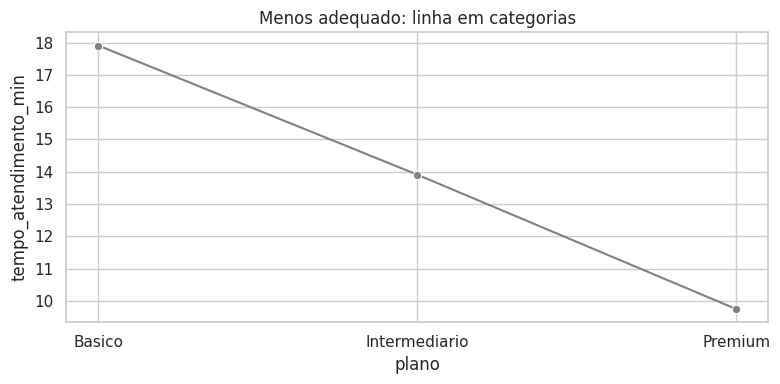

In [ ]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=media_plano, x='plano', y='tempo_atendimento_min', marker='o', color='gray')
plt.title('Menos adequado: linha em categorias')
plt.tight_layout()



**Mais adequado para este caso**

Boxplot e violinplot mostram distribuição por grupo.
        


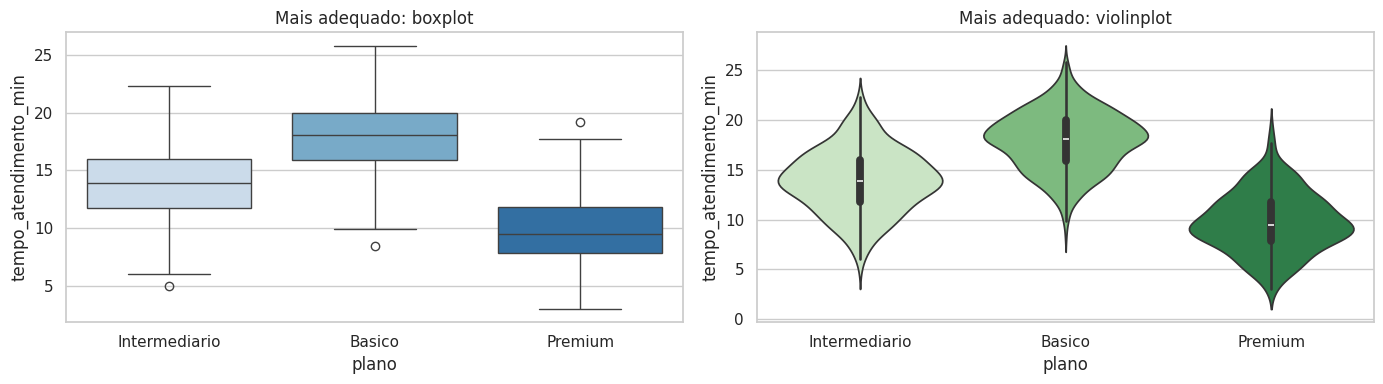

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=df_grupos,
    x='plano',
    y='tempo_atendimento_min',
    hue='plano',
    palette='Blues',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Mais adequado: boxplot')

sns.violinplot(
    data=df_grupos,
    x='plano',
    y='tempo_atendimento_min',
    hue='plano',
    palette='Greens',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Mais adequado: violinplot')

plt.tight_layout()



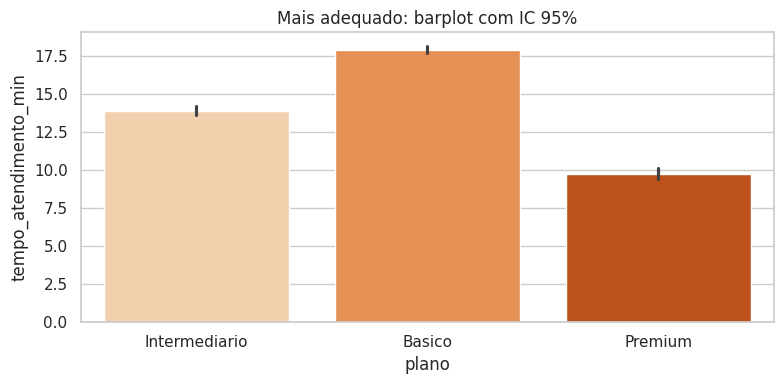

In [43]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_grupos,
    x='plano',
    y='tempo_atendimento_min',
    hue='plano',
    palette='Oranges',
    legend=False,
    estimator=np.mean,
    errorbar=('ci', 95)
)
plt.title('Mais adequado: barplot com IC 95%')
plt.tight_layout()



#### 4.4 Série temporal

**Pergunta**: qual é a tendência mensal de volume ao longo do tempo?
        


In [ ]:
datas_diarias = pd.date_range(start='2024-01-01', end=pd.Timestamp.today().normalize(), freq='D')
t = np.arange(len(datas_diarias))

volume = 280 + 0.18 * t + 22 * np.sin(2 * np.pi * t / 30) + np.random.normal(0, 14, size=len(t))
volume = np.clip(volume, 50, None)

df_tempo = pd.DataFrame({'data': datas_diarias, 'volume': volume})
df_mensal = (
    df_tempo.set_index('data')
    .resample('MS')['volume']
    .mean()
    .reset_index()
)



**Menos adequado para este caso**

Nuvem diária sem agregação pode esconder tendência por excesso de ruído.
        


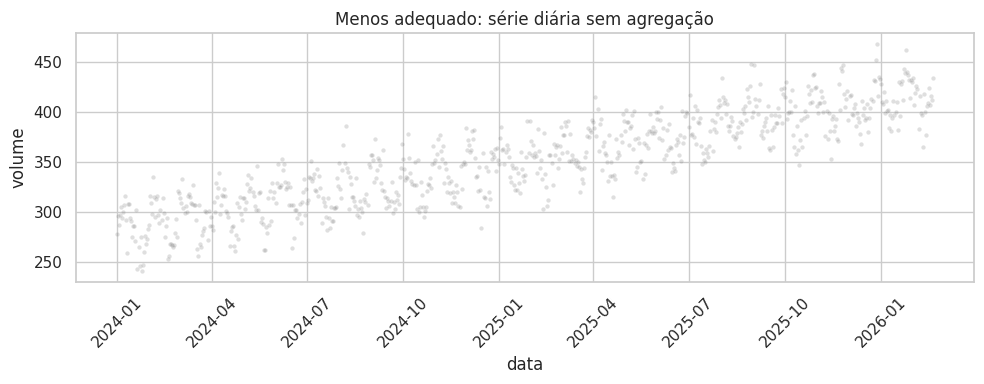

In [45]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df_tempo, x='data', y='volume', s=10, alpha=0.25, color='gray')
plt.title('Menos adequado: série diária sem agregação')
plt.xticks(rotation=45)
plt.tight_layout()



**Mais adequado para este caso**

Linha com agregação mensal evidencia a tendência ao longo do tempo.
        


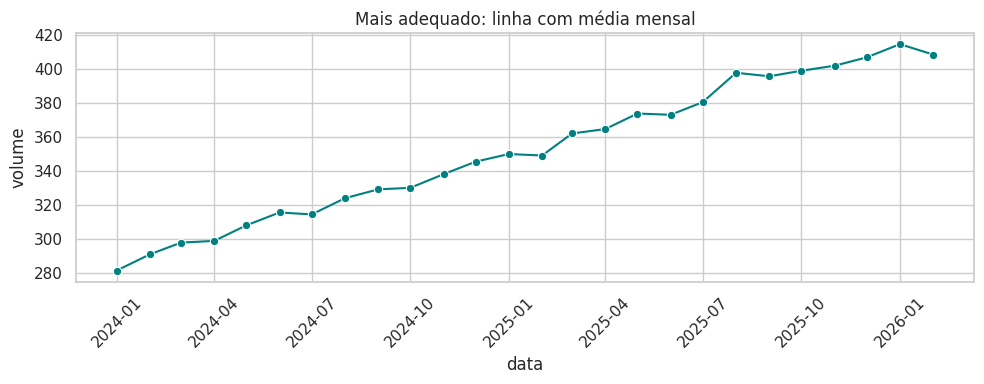

In [46]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_mensal, x='data', y='volume', marker='o', color='teal')
plt.title('Mais adequado: linha com média mensal')
plt.xticks(rotation=45)
plt.tight_layout()



### 5 - Seaborn e estimativa estatística

Seaborn pode calcular estatísticas automaticamente. No exemplo abaixo, o gráfico mostra a **média** de valor por perfil e um **IC de 95%**.
        


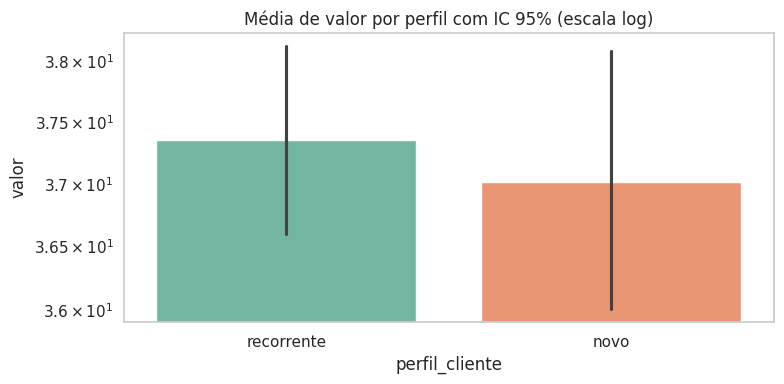

In [47]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_transacoes,
    x='perfil_cliente',
    y='valor',
    hue='perfil_cliente',
    legend=False,
    palette='Set2',
    estimator=np.mean,
    errorbar=('ci', 95)
)
plt.yscale('log')
plt.title('Média de valor por perfil com IC 95% (escala log)')
plt.tight_layout()
plt.show()



### 6 - Erros Comuns e Depuração Visual

- Escolher gráfico sem partir da pergunta analítica.
- Aplicar agregação cedo demais e esconder variabilidade.
- Usar escala inadequada para caudas longas.
- Comparar grupos sem mostrar incerteza.

**Checklist visual**
1. Qual pergunta estatística o gráfico responde?
2. O gráfico preserva a estrutura dos dados?
3. A escala e a agregação são coerentes?
4. Incerteza e volume amostral estão visíveis?
        
